In [1]:
target_cols = 'K_Nu'
input_folder=f'C:/Users/1/projects/zadachi/3 задача/{target_cols} determ'
output_file=f'{target_cols} determ.csv'

columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv(output_file)

# Подготовка данных
df['A2/A2_s'] = df['A2'] / df['А2_surface']
y = df[target_cols]
X = df[['A2/A2_s', 'F']]


C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
df

,K_Nu,K_E,K_Rho,K_incl_top_position_y,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z,A2/A2_s
0,0.8000,1,1,1,0.1,10.000000,5.331371e-13,5.331386e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446,0.999997
1,0.8000,1,1,1,0.2,5.000000,5.334869e-13,5.331507e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446,1.000631
2,0.8000,1,1,1,0.3,3.333333,5.366543e-13,5.363065e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446,1.000649
3,0.8000,1,1,1,0.4,2.500000,5.329471e-13,5.332102e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446,0.999507
4,0.8000,1,1,1,0.5,2.000000,5.331205e-13,5.332521e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446,0.999753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100095,0.8036,1,1,1,9.6,0.104167,5.367186e-13,5.358007e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446,1.001713
100096,0.8036,1,1,1,9.7,0.103093,5.369076e-13,5.359525e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446,1.001782
100097,0.8036,1,1,1,9.8,0.102041,5.370946e-13,5.361025e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446,1.001850
100098,0.8036,1,1,1,9.9,0.101010,5.372790e-13,5.362506e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446,1.001918


In [4]:
def create_and_train_model(X_train, y_train, X_test, y_test, sample_size):
    """Создает и обучает модель на данных заданного размера"""
    
    scaler_X = StandardScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Создание модели
    model = Sequential([
        Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
        Dropout(0.2),  # Добавляем Dropout для регуляризации
        Dense(64, activation='relu', name='hidden_layer_2'),
        Dropout(0.2),
        Dense(1, name='output_layer')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Ранняя остановка
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )
    
    # Обучение
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=min(32, len(X_train)//10),
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Предсказание
    y_pred = np.array(model.predict(X_test_scaled)).flatten()
    y_test = np.array(y_test)
    
    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Относительная ошибка
    relative_errors = np.abs((y_test - y_pred) / y_test) * 100
    mean_relative_error = np.mean(relative_errors)
    std_relative_error = np.std(relative_errors)
    
    return {
        'sample_size': sample_size,
        'mse': mse,
        'mae': mae,
        'mape': mape,
        'rmse': rmse,
        'r2': r2,
        'mean_rel_error': mean_relative_error,
        'std_rel_error': std_relative_error,
        'accuracy': 100 - mean_relative_error,
        'history': history.history
    }

# Основной анализ
print("="*70)
print("АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ДАННЫХ НА КАЧЕСТВО ПРЕДСКАЗАНИЯ K_E")
print("="*70)

# Размеры выборок для анализа
sample_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
n_repetitions = 3  # Количество повторений для каждого размера (для усреднения)

results = []

# Фиксируем тестовую выборку (20% от всех данных)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ДАННЫХ НА КАЧЕСТВО ПРЕДСКАЗАНИЯ K_E


In [ ]:

print(f"\nТестовая выборка фиксирована: {len(X_test)} образцов")
print(f"Обучающая выборка (полная): {len(X_train_full)} образцов")
print("\n" + "-"*70)

for size in sample_sizes:
    print(f"\nАнализ для размера выборки: {size}")
    
    size_results = []
    
    for rep in range(n_repetitions):
        # Случайно выбираем size образцов из обучающей выборки
        indices = np.random.choice(len(X_train_full), size=min(size, len(X_train_full)), replace=False)
        X_train_sample = X_train_full.iloc[indices]
        y_train_sample = y_train_full.iloc[indices]
        
        # Обучаем и оцениваем модель
        result = create_and_train_model(
            X_train_sample, y_train_sample,
            X_test, y_test,
            size
        )
        size_results.append(result)
        
        print(f"  Повторение {rep+1}/{n_repetitions}: "
              f"Точность = {result['accuracy']:.2f}%")
    
    # Усредняем результаты по повторениям
    avg_result = {
        'sample_size': size,
        'mse': np.mean([r['mse'] for r in size_results]),
        'mae': np.mean([r['mae'] for r in size_results]),
        'mape': np.mean([r['mape'] for r in size_results]),
        'rmse': np.mean([r['rmse'] for r in size_results]),
        'r2': np.mean([r['r2'] for r in size_results]),
        'mean_rel_error': np.mean([r['mean_rel_error'] for r in size_results]),
        'std_rel_error': np.mean([r['std_rel_error'] for r in size_results]),
        'accuracy': np.mean([r['accuracy'] for r in size_results]),
        'accuracy_std': np.std([r['accuracy'] for r in size_results])
    }
    
    results.append(avg_result)
    
    print(f"\n  СРЕДНЕЕ для размера {size}:")
    print(f"    Точность: {avg_result['accuracy']:.2f}% ± {avg_result['accuracy_std']:.2f}%")
    print(f"    R²: {avg_result['r2']:.4f}")
    print(f"    RMSE: {avg_result['rmse']:.6f}")
    print(f"    MAE: {avg_result['mae']:.6f}")
    print(f"    MAPE: {avg_result['mape']:.6f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df.to_csv(f'{target_cols} size result.csv', index=False)
print('Датасет сохранен')


Тестовая выборка фиксирована: 20020 образцов
Обучающая выборка (полная): 80080 образцов

----------------------------------------------------------------------

Анализ для размера выборки: 100


626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
  Повторение 1/3: Точность = 92.55%
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
  Повторение 2/3: Точность = 93.58%
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
  Повторение 3/3: Точность = 93.65%

  СРЕДНЕЕ для размера 100:
    Точность: 93.26% ± 0.50%
    R²: 0.4251
    RMSE: 0.087434
    MAE: 0.065929
    MAPE: 0.067413

Анализ для размера выборки: 200
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
  Повторение 1/3: Точность = 94.22%
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
  Повторение 2/3: Точность = 93.93%
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 3/3: Точность = 93.61%

  СРЕДНЕЕ для размера 200:
    Точность: 93.92% ± 0.25%
    R²: 0.5105
    RMSE: 0.080760
    MAE: 0.059864
    MAPE: 0.060800

Анализ для размера выборки: 500
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
  Повторение 1/3: Точность = 94.94%
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 2/3: Точность = 94.87%
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
  Повторение 3/3: Точ

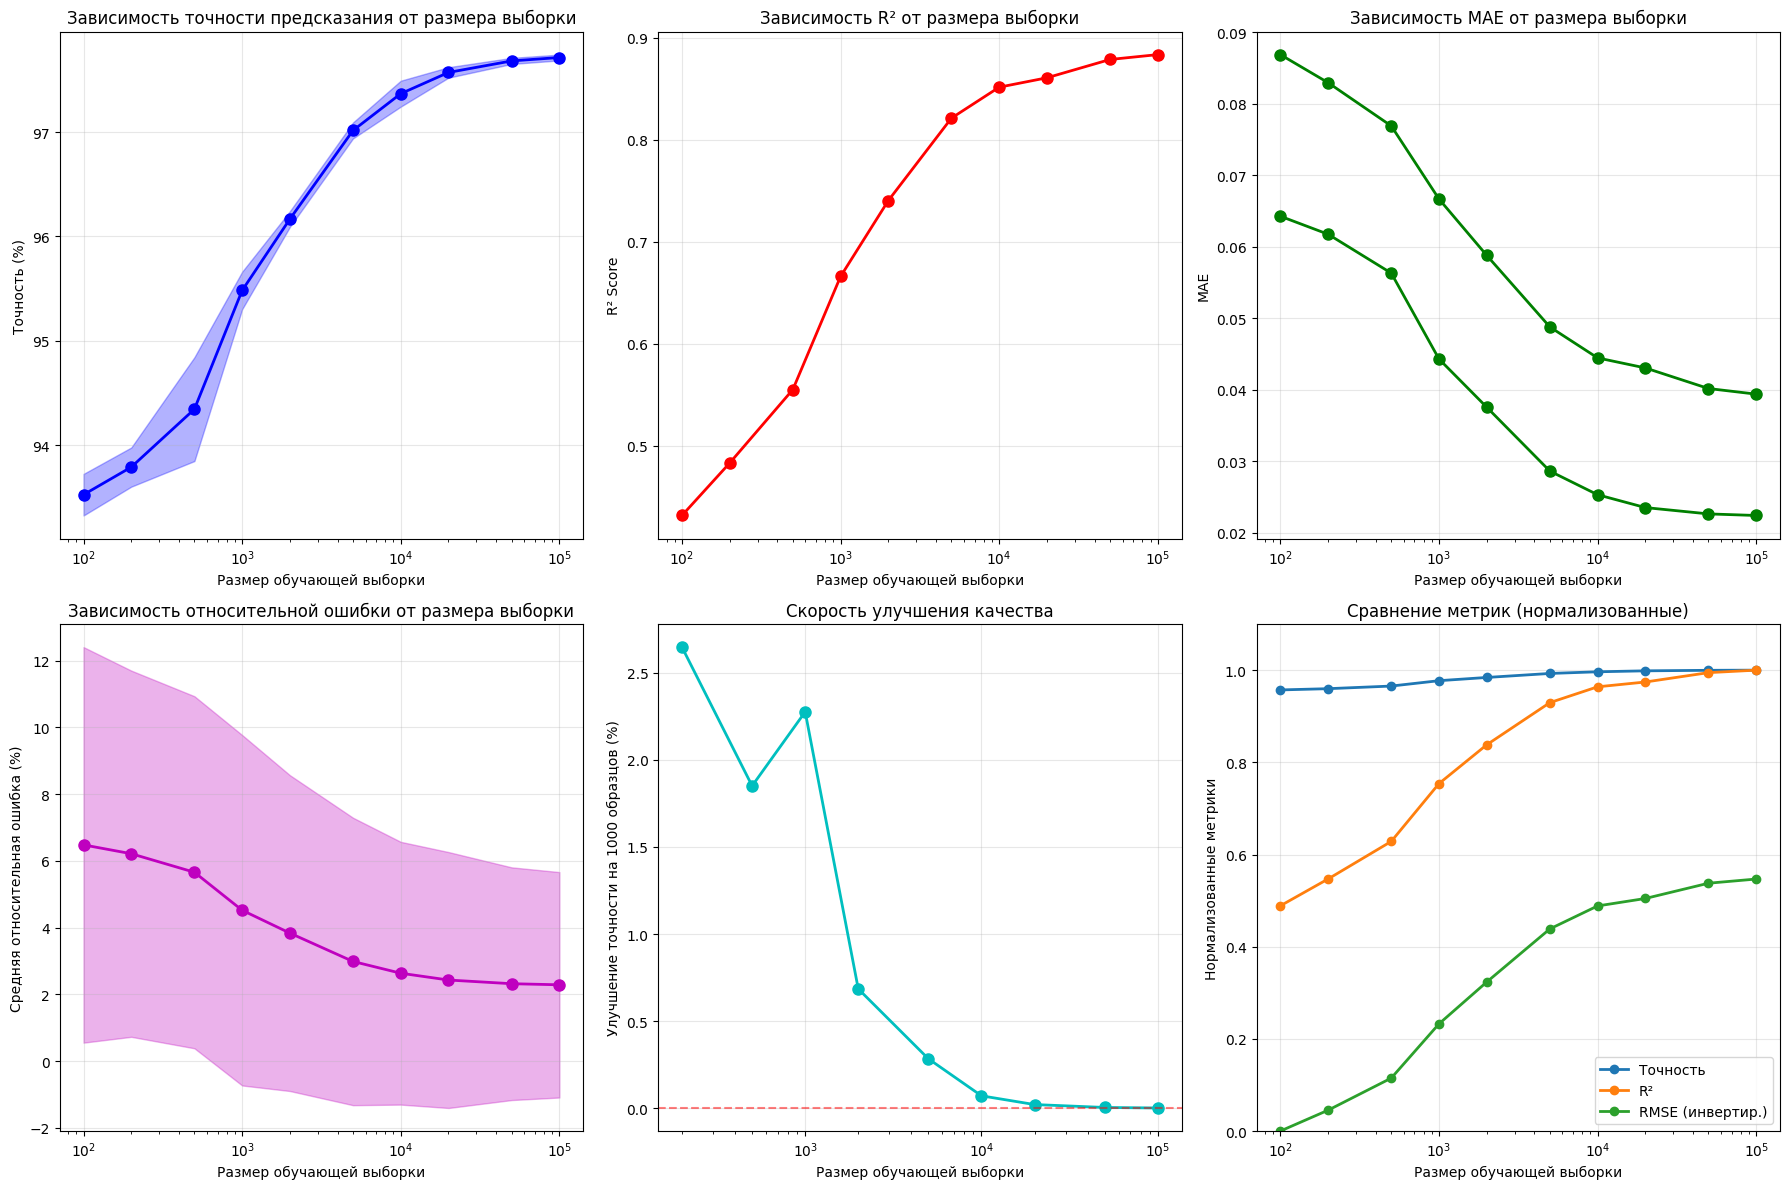

In [ ]:

# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))


# 2. R² от размера выборки
axes[0, 0].plot(results_df['sample_size'], results_df['r2'], 'ro-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Размер обучающей выборки')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Зависимость R² от размера выборки')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# 3. RMSE от размера выборки
axes[0, 1].plot(results_df['sample_size'], results_df['rmse'], 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Размер обучающей выборки')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('Зависимость RMSE от размера выборки')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# 3.2 MAE от размера выборки
axes[0, 2].plot(results_df['sample_size'], results_df['mae'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Размер обучающей выборки')
axes[0, 2].set_ylabel('MAE')
axes[0, 2].set_title('Зависимость MAE от размера выборки')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# 4. Относительная ошибка от размера выборки
axes[1, 0].plot(results_df['sample_size'], results_df['mean_rel_error'], 'mo-', linewidth=2, markersize=8)
axes[1, 0].fill_between(results_df['sample_size'],
                        results_df['mean_rel_error'] - results_df['std_rel_error'],
                        results_df['mean_rel_error'] + results_df['std_rel_error'],
                        alpha=0.3, color='m')
axes[1, 0].set_xlabel('Размер обучающей выборки')
axes[1, 0].set_ylabel(' MAPE (%)')
axes[1, 0].set_title('Зависимость MAPE от размера выборки')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# 5. Скорость обучения (время/качество)
improvement = []
for i in range(1, len(results_df)):
    imp = (results_df['accuracy'].iloc[i] - results_df['accuracy'].iloc[i-1]) / \
          (results_df['sample_size'].iloc[i] - results_df['sample_size'].iloc[i-1])
    improvement.append(imp * 1000)  # Умножаем для лучшей визуализации

axes[1, 1].plot(results_df['sample_size'].iloc[1:], improvement, 'co-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Размер обучающей выборки')
axes[1, 1].set_ylabel('Улучшение точности на 1000 образцов (%)')
axes[1, 1].set_title('Скорость улучшения качества')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 6. Сравнение метрик (нормализованные)
metrics_normalized = pd.DataFrame({
    'Точность': results_df['accuracy'] / results_df['accuracy'].max(),
    'R²': results_df['r2'] / results_df['r2'].max(),
    'RMSE (инвертир.)': 1 - results_df['rmse'] / results_df['rmse'].max()
})

for metric in metrics_normalized.columns:
    axes[1, 2].plot(results_df['sample_size'], metrics_normalized[metric], 
                   'o-', linewidth=2, markersize=6, label=metric)

axes[1, 2].set_xlabel('Размер обучающей выборки')
axes[1, 2].set_ylabel('Нормализованные метрики')
axes[1, 2].set_title('Сравнение метрик (нормализованные)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xscale('log')
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

In [ ]:
results_df

,sample_size,mse,mae,mape,rmse,r2,mean_rel_error,std_rel_error,accuracy,accuracy_std
0,100,0.007571,0.064284,0.064763,0.086903,0.431844,6.476264,5.925584,93.523736,0.199314
1,200,0.006885,0.061763,0.062114,0.082972,0.483293,6.211429,5.486176,93.788571,0.187833
2,500,0.005927,0.056324,0.056561,0.076924,0.555244,5.656117,5.274400,94.343883,0.497569
3,1000,0.004449,0.044302,0.045178,0.066692,0.666105,4.517822,5.250078,95.482178,0.179545
4,2000,0.003458,0.037557,0.038330,0.058804,0.740499,3.833043,4.731437,96.166957,0.075320
5,5000,0.002381,0.028619,0.029835,0.048791,0.821314,2.983519,4.306437,97.016481,0.076411
6,10000,0.001977,0.025312,0.026308,0.044460,0.851647,2.630842,3.936297,97.369158,0.124287
7,20000,0.001854,0.023513,0.024273,0.043054,0.860861,2.427320,3.834102,97.572680,0.050278
8,50000,0.001615,0.022628,0.023168,0.040175,0.878813,2.316776,3.486195,97.683224,0.029148
9,100000,0.001551,0.022407,0.022841,0.039387,0.883579,2.284146,3.376970,97.715854,0.027836
